# Final Project Notebookv - Code

DS 5001 Text as Data

# Metadata

- Full Name: Shawn Ding, Tianyin Mao
- Userid: exf7sx, qhh3bv

# Parsed and Annotated Data

Parse the raw data into the three core tables of your addition: the `LIB`, `CORPUS`, and `VOCAB` tables.

These tables will be stored as CSV files with header rows.

You may consider using `|` as a delimitter.

Provide the following information for each.

In [35]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from gensim.models import Word2Vec
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
nltk.download('averaged_perceptron_tagger_eng')

# It's also good practice to ensure these are present
nltk.download('punkt')
nltk.download('punkt_tab')
# Download necessary NLTK data
nltk.download(['punkt', 'averaged_perceptron_tagger', 'stopwords', 'vader_lexicon', 'punkt_tab'])

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/NovaMist/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /Users/NovaMist/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/NovaMist/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/NovaMist/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/NovaMist/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/NovaMist/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]    

True

In [36]:
# Load Data
df = pd.read_csv('output/i_ching_paragraphs.csv')
df.head()

,doc_id,doc_type,title,url,hexagram_img,para_num,para_text,word_count
0,0,hexagram,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,1,Explanation of the entire figure by king Wăn,8
1,0,hexagram,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,2,Khien (represents) what is great and originati...,12
2,0,hexagram,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,3,Explanation of the separate lines by the duke ...,10
3,0,hexagram,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,4,"1. In the first (or lowest) NINE, undivided, (...",28
4,0,hexagram,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,5,"2. In the second NINE, undivided, (we see its ...",27


## LIB (2)

The source documents the corpus comprises. These may be books, plays, newspaper articles, abstracts, blog posts, etc. 

Note that these are *not* documents in the sense used to describe a bag-of-words representation of a text, e.g. chapter.

- Delimitter: `|`
- Number of observations: 75
- List of features, including at least three that may be used for model summarization (e.g. date, author, etc.):

['title', 'url', 'hexagram_img', 'doc_type', 'num_paras', 'total_words', 'author', 'year', 'language', 'source_url', 'genre', 'hexagram_id', 'canon', 'modern_name', 'chinese', 'english', 'upper_trigram', 'upper_trigram_symbol', 'upper_trigram_element', 'lower_trigram', 'lower_trigram_symbol', 'lower_trigram_element']

- Average length of each document in characters: 9,176

In [37]:
# Reduce to one row per document
LIB = (
    df.groupby('doc_id')
    .agg(
        title = ('title', 'first'),
        url = ('url', 'first'),
        hexagram_img = ('hexagram_img', 'first'),
        doc_type = ('doc_type', 'first'),
        num_paras = ('para_num', 'count'),
        total_words = ('word_count', 'sum'),
    )
    .reset_index()
    .set_index('doc_id')
)

LIB.head()

,title,url,hexagram_img,doc_type,num_paras,total_words
doc_id,,,,,,
0,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,hexagram,17,1026
1,II. The Khwăn Hexagram,https://sacred-texts.com/ich/ic02.htm,https://sacred-texts.com/ich/img/hex000000.jpg,hexagram,13,693
2,III. The Kun Hexagram,https://sacred-texts.com/ich/ic03.htm,https://sacred-texts.com/ich/img/hex010001.jpg,hexagram,15,912
3,IV. The Măng Hexagram,https://sacred-texts.com/ich/ic04.htm,https://sacred-texts.com/ich/img/hex100010.jpg,hexagram,16,657
4,V. The Hsü Hexagram,https://sacred-texts.com/ich/ic05.htm,https://sacred-texts.com/ich/img/hex010111.jpg,hexagram,16,696


In [38]:
# Add the missing metadata identified in your project description
LIB['author'] = 'James Legge'
LIB['year'] = 1899
LIB['language'] = 'English'
LIB['source_url'] = 'https://sacred-texts.com/ich/index.htm'
LIB['genre'] = 'Philosophical/Divination'

In [39]:
# Add Hexagram_id
LIB['hexagram_id'] = None
LIB.loc[LIB.index < 64, 'hexagram_id'] = LIB.index[LIB.index < 64] + 1

In [40]:
# Add Canon metadata — useful for colouring PCA plots later
# Upper Canon (hexagrams 1–30): Opens with Qian (☰ Heaven) and Kun (☷ Earth), the two primordial forces. This section deals with cosmological principles — the fundamental nature of heaven, earth, and the universe.
# Lower Canon (hexagrams 31–64): Opens with Xian (Influence) and Heng (Perseverance), and shifts toward human affairs — relationships, social dynamics, family, and governance.
LIB['canon'] = 'Appendix'
LIB.loc[LIB.index < 30, 'canon'] = 'Upper Canon (hex 1-30)'
LIB.loc[(LIB.index >= 30) & (LIB.index < 64), 'canon'] = 'Lower Canon (hex 31-64)'

In [41]:
# see the Hexagram Image, use this as an reference to add in Modern Name, Upper/lower Canon, and Upper/Lower trigrams
from IPython.display import HTML

def render_lib(df, img_col='hexagram_img', img_size=60):
    """Display LIB with hexagram images rendered inline."""
    def make_img(url):
        if pd.isna(url):
            return ''
        return f'<img src="{url}" width="{img_size}">'
    
    styled = df.copy()
    styled[img_col] = styled[img_col].apply(make_img)
    return HTML(styled.to_html(escape=False))

render_lib(LIB)

,title,url,hexagram_img,doc_type,num_paras,total_words,author,year,language,source_url,genre,hexagram_id,canon
doc_id,,,,,,,,,,,,,
0,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,,hexagram,17,1026,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,1,Upper Canon (hex 1-30)
1,II. The Khwăn Hexagram,https://sacred-texts.com/ich/ic02.htm,,hexagram,13,693,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,2,Upper Canon (hex 1-30)
2,III. The Kun Hexagram,https://sacred-texts.com/ich/ic03.htm,,hexagram,15,912,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,3,Upper Canon (hex 1-30)
3,IV. The Măng Hexagram,https://sacred-texts.com/ich/ic04.htm,,hexagram,16,657,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,4,Upper Canon (hex 1-30)
4,V. The Hsü Hexagram,https://sacred-texts.com/ich/ic05.htm,,hexagram,16,696,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,5,Upper Canon (hex 1-30)
5,VI. The Sung Hexagram,https://sacred-texts.com/ich/ic06.htm,,hexagram,16,896,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,6,Upper Canon (hex 1-30)
6,VII. The Sze Hexagram,https://sacred-texts.com/ich/ic07.htm,,hexagram,15,795,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,7,Upper Canon (hex 1-30)
7,VIII. The Pî Hexagram,https://sacred-texts.com/ich/ic08.htm,,hexagram,16,800,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,8,Upper Canon (hex 1-30)
8,IX. The HsiâoKhû Hexagram,https://sacred-texts.com/ich/ic09.htm,,hexagram,16,859,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,9,Upper Canon (hex 1-30)


In [42]:
# Add Modern Name for all the Hexagram rows

MODERN_NAMES = {
    0:  ('Qian',      '乾', 'The Creative'),
    1:  ('Kun',       '坤', 'The Receptive'),
    2:  ('Zhun',      '屯', 'Difficulty at the Beginning'),
    3:  ('Meng',      '蒙', 'Youthful Folly'),
    4:  ('Xu',        '需', 'Waiting'),
    5:  ('Song',      '讼', 'Conflict'),
    6:  ('Shi',       '师', 'The Army'),
    7:  ('Bi',        '比', 'Holding Together'),
    8:  ('Xiao Xu',   '小畜', 'Small Taming'),
    9:  ('Li',        '履', 'Treading'),
    10: ('Tai',       '泰', 'Peace'),
    11: ('Pi',        '否', 'Standstill'),
    12: ('Tong Ren',  '同人', 'Fellowship'),
    13: ('Da You',    '大有', 'Great Possession'),
    14: ('Qian',      '谦', 'Modesty'),
    15: ('Yu',        '豫', 'Enthusiasm'),
    16: ('Sui',       '随', 'Following'),
    17: ('Gu',        '蛊', 'Work on the Decayed'),
    18: ('Lin',       '临', 'Approach'),
    19: ('Guan',      '观', 'Contemplation'),
    20: ('Shi He',    '噬嗑', 'Biting Through'),
    21: ('Bi',        '贲', 'Grace'),
    22: ('Bo',        '剥', 'Splitting Apart'),
    23: ('Fu',        '复', 'Return'),
    24: ('Wu Wang',   '无妄', 'Innocence'),
    25: ('Da Xu',     '大畜', 'Great Taming'),
    26: ('Yi',        '颐', 'Nourishment'),
    27: ('Da Guo',    '大过', 'Great Excess'),
    28: ('Kan',       '坎', 'The Abysmal'),
    29: ('Li',        '离', 'The Clinging / Fire'),
    30: ('Xian',      '咸', 'Influence'),
    31: ('Heng',      '恒', 'Duration'),
    32: ('Dun',       '遯', 'Retreat'),
    33: ('Da Zhuang', '大壮', 'Great Power'),
    34: ('Jin',       '晋', 'Progress'),
    35: ('Ming Yi',   '明夷', 'Darkening of the Light'),
    36: ('Jia Ren',   '家人', 'The Family'),
    37: ('Kui',       '睽', 'Opposition'),
    38: ('Jian',      '蹇', 'Obstruction'),
    39: ('Jie',       '解', 'Deliverance'),
    40: ('Sun',       '损', 'Decrease'),
    41: ('Yi',        '益', 'Increase'),
    42: ('Guai',      '夬', 'Breakthrough'),
    43: ('Gou',       '姤', 'Coming to Meet'),
    44: ('Cui',       '萃', 'Gathering Together'),
    45: ('Sheng',     '升', 'Pushing Upward'),
    46: ('Kun',       '困', 'Oppression'),
    47: ('Jing',      '井', 'The Well'),
    48: ('Ge',        '革', 'Revolution'),
    49: ('Ding',      '鼎', 'The Cauldron'),
    50: ('Zhen',      '震', 'The Arousing'),
    51: ('Gen',       '艮', 'Keeping Still'),
    52: ('Jian',      '渐', 'Development'),
    53: ('Gui Mei',   '归妹', 'The Marrying Maiden'),
    54: ('Feng',      '丰', 'Abundance'),
    55: ('Lu',        '旅', 'The Wanderer'),
    56: ('Xun',       '巽', 'The Gentle'),
    57: ('Dui',       '兑', 'The Joyous'),
    58: ('Huan',      '涣', 'Dispersion'),
    59: ('Jie',       '节', 'Limitation'),
    60: ('Zhong Fu',  '中孚', 'Inner Truth'),
    61: ('Xiao Guo',  '小过', 'Small Excess'),
    62: ('Ji Ji',     '既济', 'After Completion'),
    63: ('Wei Ji',    '未济', 'Before Completion'),
}

# Add to LIB
LIB['modern_name']  = LIB.index.map(lambda i: MODERN_NAMES[i][0] if i in MODERN_NAMES else None)
LIB['chinese'] = LIB.index.map(lambda i: MODERN_NAMES[i][1] if i in MODERN_NAMES else None)
LIB['english'] = LIB.index.map(lambda i: MODERN_NAMES[i][2] if i in MODERN_NAMES else None)
LIB.head()

,title,url,hexagram_img,doc_type,num_paras,total_words,author,year,language,source_url,genre,hexagram_id,canon,modern_name,chinese,english
doc_id,,,,,,,,,,,,,,,,
0,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,hexagram,17,1026,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,1,Upper Canon (hex 1-30),Qian,乾,The Creative
1,II. The Khwăn Hexagram,https://sacred-texts.com/ich/ic02.htm,https://sacred-texts.com/ich/img/hex000000.jpg,hexagram,13,693,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,2,Upper Canon (hex 1-30),Kun,坤,The Receptive
2,III. The Kun Hexagram,https://sacred-texts.com/ich/ic03.htm,https://sacred-texts.com/ich/img/hex010001.jpg,hexagram,15,912,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,3,Upper Canon (hex 1-30),Zhun,屯,Difficulty at the Beginning
3,IV. The Măng Hexagram,https://sacred-texts.com/ich/ic04.htm,https://sacred-texts.com/ich/img/hex100010.jpg,hexagram,16,657,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,4,Upper Canon (hex 1-30),Meng,蒙,Youthful Folly
4,V. The Hsü Hexagram,https://sacred-texts.com/ich/ic05.htm,https://sacred-texts.com/ich/img/hex010111.jpg,hexagram,16,696,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination,5,Upper Canon (hex 1-30),Xu,需,Waiting


In [43]:
# Add Trigrams and Upper/Lower Trigram
# Upper trigram (outer) represents the external situation — the environment, social forces, and circumstances you are responding to but cannot fully control.
# Lower trigram (inner) represents the internal condition — your own position, disposition, and the foundation from which you act.

TRIGRAMS = {
    'Qian': ('☰', 'Heaven'),
    'Kun':  ('☷', 'Earth'),
    'Zhen': ('☳', 'Thunder'),
    'Kan':  ('☵', 'Water'),
    'Gen':  ('☶', 'Mountain'),
    'Dui':  ('☱', 'Lake'),
    'Xun':  ('☴', 'Wind'),
    'Li':   ('☲', 'Fire'),
}

# (upper_trigram, lower_trigram) for hexagrams 0–63
HEXAGRAM_TRIGRAMS = [
    ('Qian','Qian'), ('Kun','Kun'),   ('Kan','Zhen'),  ('Gen','Kan'),
    ('Kan','Qian'),  ('Qian','Kan'),  ('Kun','Kan'),   ('Kan','Kun'),
    ('Xun','Qian'),  ('Qian','Dui'),  ('Kun','Qian'),  ('Qian','Kun'),
    ('Qian','Li'),   ('Li','Qian'),   ('Kun','Gen'),   ('Zhen','Kun'),
    ('Dui','Zhen'),  ('Gen','Xun'),   ('Kun','Dui'),   ('Xun','Kun'),
    ('Li','Zhen'),   ('Gen','Li'),    ('Gen','Kun'),   ('Kun','Zhen'),
    ('Qian','Zhen'), ('Gen','Qian'),  ('Gen','Zhen'),  ('Dui','Xun'),
    ('Kan','Kan'),   ('Li','Li'),     ('Dui','Gen'),   ('Zhen','Xun'),
    ('Qian','Gen'),  ('Zhen','Qian'), ('Li','Kun'),    ('Kun','Li'),
    ('Xun','Li'),    ('Li','Dui'),    ('Kan','Gen'),   ('Zhen','Kan'),
    ('Gen','Dui'),   ('Xun','Zhen'),  ('Dui','Qian'),  ('Qian','Xun'),
    ('Dui','Kun'),   ('Kun','Xun'),   ('Dui','Kan'),   ('Kan','Xun'),
    ('Dui','Li'),    ('Li','Xun'),    ('Zhen','Zhen'), ('Gen','Gen'),
    ('Xun','Gen'),   ('Zhen','Dui'),  ('Zhen','Li'),   ('Li','Gen'),
    ('Xun','Xun'),   ('Dui','Dui'),   ('Xun','Kan'),   ('Kan','Dui'),
    ('Xun','Dui'),   ('Zhen','Gen'),  ('Kan','Li'),    ('Li','Kan'),
]

# Add to LIB (hexagram rows only; appendix rows get None)
for doc_id, (upper, lower) in enumerate(HEXAGRAM_TRIGRAMS):
    LIB.loc[doc_id, 'upper_trigram']         = upper
    LIB.loc[doc_id, 'upper_trigram_symbol']  = TRIGRAMS[upper][0]
    LIB.loc[doc_id, 'upper_trigram_element'] = TRIGRAMS[upper][1]
    LIB.loc[doc_id, 'lower_trigram']         = lower
    LIB.loc[doc_id, 'lower_trigram_symbol']  = TRIGRAMS[lower][0]
    LIB.loc[doc_id, 'lower_trigram_element'] = TRIGRAMS[lower][1]

,title,url,hexagram_img,doc_type,num_paras,total_words,author,year,language,source_url,...,canon,modern_name,chinese,english,upper_trigram,upper_trigram_symbol,upper_trigram_element,lower_trigram,lower_trigram_symbol,lower_trigram_element
doc_id,,,,,,,,,,,,,,,,,,,,,
0,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,hexagram,17,1026,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Qian,乾,The Creative,Qian,☰,Heaven,Qian,☰,Heaven
1,II. The Khwăn Hexagram,https://sacred-texts.com/ich/ic02.htm,https://sacred-texts.com/ich/img/hex000000.jpg,hexagram,13,693,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Kun,坤,The Receptive,Kun,☷,Earth,Kun,☷,Earth
2,III. The Kun Hexagram,https://sacred-texts.com/ich/ic03.htm,https://sacred-texts.com/ich/img/hex010001.jpg,hexagram,15,912,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Zhun,屯,Difficulty at the Beginning,Kan,☵,Water,Zhen,☳,Thunder
3,IV. The Măng Hexagram,https://sacred-texts.com/ich/ic04.htm,https://sacred-texts.com/ich/img/hex100010.jpg,hexagram,16,657,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Meng,蒙,Youthful Folly,Gen,☶,Mountain,Kan,☵,Water
4,V. The Hsü Hexagram,https://sacred-texts.com/ich/ic05.htm,https://sacred-texts.com/ich/img/hex010111.jpg,hexagram,16,696,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Xu,需,Waiting,Kan,☵,Water,Qian,☰,Heaven


In [142]:
# Save results
LIB.to_csv('output/LIB.csv', sep='|')
print(f"LIB: {len(LIB)} documents")
print(f"\nFeatures:\n{LIB.columns.tolist()}")

# Average document length in characters
avg_chars = df.groupby('doc_id')['para_text'].apply(lambda x: x.str.len().sum()).mean()
print(f"\nAverage document length (characters): {avg_chars:,.0f}")

LIB.head()

LIB: 75 documents

Features:
['title', 'url', 'hexagram_img', 'doc_type', 'num_paras', 'total_words', 'author', 'year', 'language', 'source_url', 'genre', 'hexagram_id', 'canon', 'modern_name', 'chinese', 'english', 'upper_trigram', 'upper_trigram_symbol', 'upper_trigram_element', 'lower_trigram', 'lower_trigram_symbol', 'lower_trigram_element']

Average document length (characters): 9,176


,title,url,hexagram_img,doc_type,num_paras,total_words,author,year,language,source_url,...,canon,modern_name,chinese,english,upper_trigram,upper_trigram_symbol,upper_trigram_element,lower_trigram,lower_trigram_symbol,lower_trigram_element
doc_id,,,,,,,,,,,,,,,,,,,,,
0,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,hexagram,17,1026,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Qian,乾,The Creative,Qian,☰,Heaven,Qian,☰,Heaven
1,II. The Khwăn Hexagram,https://sacred-texts.com/ich/ic02.htm,https://sacred-texts.com/ich/img/hex000000.jpg,hexagram,13,693,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Kun,坤,The Receptive,Kun,☷,Earth,Kun,☷,Earth
2,III. The Kun Hexagram,https://sacred-texts.com/ich/ic03.htm,https://sacred-texts.com/ich/img/hex010001.jpg,hexagram,15,912,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Zhun,屯,Difficulty at the Beginning,Kan,☵,Water,Zhen,☳,Thunder
3,IV. The Măng Hexagram,https://sacred-texts.com/ich/ic04.htm,https://sacred-texts.com/ich/img/hex100010.jpg,hexagram,16,657,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Meng,蒙,Youthful Folly,Gen,☶,Mountain,Kan,☵,Water
4,V. The Hsü Hexagram,https://sacred-texts.com/ich/ic05.htm,https://sacred-texts.com/ich/img/hex010111.jpg,hexagram,16,696,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,...,Upper Canon (hex 1-30),Xu,需,Waiting,Kan,☵,Water,Qian,☰,Heaven


## CORPUS (2)

The sequence of word tokens in the corpus, indexed by their location in the corpus and document structures.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: `|`
- Number of observations Between (should be >= 500,000 and <= 2,000,000 observations.): 123,763
- OHCO Structure (as delimitted column names): ['doc_id','para_num','sent_num','token_num']
- Columns (as delimitted column names, including `token_str`, `term_str`, `pos`, and `pos_group`): ['token_str', 'term_str', 'pos', 'pos_group']

In [48]:
# Build Function for Corpus Table
def tokenize_corpus(df):
    rows = []
    for _, row in df.iterrows():
        sentences = sent_tokenize(str(row['para_text']))
        for s_idx, sent in enumerate(sentences):
            tokens = word_tokenize(sent)
            for t_idx, token in enumerate(tokens):
                rows.append((
                    int(row['doc_id']),
                    int(row['para_num']),
                    s_idx,
                    t_idx,
                    token
                ))

    CORPUS = pd.DataFrame(rows, columns=['doc_id','para_num','sent_num','token_num','token_str'])
    CORPUS = CORPUS.set_index(['doc_id','para_num','sent_num','token_num'])

    # term_str: lowercase, strip non-alpha (keeps accented chars like ă, â)
    CORPUS['term_str'] = (CORPUS['token_str']
                          .str.lower()
                          .str.replace(r'[^\w\s]', '', regex=True)
                          .str.strip())
    CORPUS = CORPUS[CORPUS['term_str'] != '']

    # POS tagging — batch for speed
    tokens_flat = CORPUS['token_str'].tolist()
    pos_tags = nltk.pos_tag(tokens_flat)
    CORPUS['pos'] = [p[1] for p in pos_tags]
    CORPUS['pos_group'] = CORPUS['pos'].str[:2]

    return CORPUS

In [51]:
# --- Create Corpus Table ---
CORPUS = tokenize_corpus(df)

print(f"CORPUS rows    : {len(CORPUS):,}")
print(f"OHCO structure : {CORPUS.index.names}")
print(f"Columns        : {CORPUS.columns.tolist()}")
CORPUS.head(10)

CORPUS rows    : 123,763
OHCO structure : ['doc_id', 'para_num', 'sent_num', 'token_num']
Columns        : ['token_str', 'term_str', 'pos', 'pos_group']


token_str     term_str  pos pos_group
doc_id para_num sent_num token_num                                         
0      1        0        0          Explanation  explanation   NN        NN
                         1                   of           of   IN        IN
                         2                  the          the   DT        DT
                         3               entire       entire   JJ        JJ
                         4               figure       figure   NN        NN
                         5                   by           by   IN        IN
                         6                 king         king  VBG        VB
                         7                  Wăn          wăn  NNP        NN
       2        0        0                Khien        khien  NNP        NN
                         2           represents   represents  VBZ        VB

In [53]:
# --- Save Results ---
CORPUS.to_csv('output/CORPUS.csv', sep='|')

## VOCAB (2)

The unique word types (terms) in the corpus.

- Delimitter:`|`
- Number of observations: 6,512
- Columns (as delimitted names, including `n`, `p`', `i`, `dfidf`, `porter_stem`, `max_pos` and `max_pos_group`, `stop`): ['n', 'p', 'i', 'stop', 'porter_stem', 'max_pos', 'max_pos_group', 'dfidf']
- Note: Your VOCAB may contain ngrams. If so, add a feature for `ngram_length`.
- List the top 20 significant words in the corpus by DFIDF.

Top 20 Significant Words by DFIDF:
['line', 'subject', 'shows', 'good', 'place', 'great', 'undivided', 'paragraph', 'fortune', 'divided', 'strong', 'lines', 'weak', 'man', 'position', 'correct', 'proper', 'firm', 'hexagram', 'heaven']

In [61]:
# -- Build VOCAB --
VOCAB = CORPUS['term_str'].value_counts().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['p'] = VOCAB['n'] / VOCAB['n'].sum()
VOCAB['i'] = -np.log2(VOCAB['p']) # Information (Entropy)

In [64]:
# Remove empty strings and pure punctuation
VOCAB = VOCAB[VOCAB.index.str.strip() != '']
VOCAB = VOCAB[VOCAB.index.str.contains(r'[a-zA-Z]', regex=True)]

In [62]:
# -- Add Stopwords and Stems --
sw = stopwords.words('english')
ps = PorterStemmer()
VOCAB['stop'] = VOCAB.index.isin(sw).astype(int)
VOCAB['porter_stem'] = [ps.stem(word) for word in VOCAB.index]

In [63]:
# -- Add POS metadata --
# We find the most frequent POS tag for each word in the CORPUS
pos_counts = CORPUS.groupby(['term_str', 'pos']).size().unstack(fill_value=0)
VOCAB['max_pos'] = pos_counts.idxmax(axis=1)
VOCAB['max_pos_group'] = VOCAB['max_pos'].str[:2] # Usually NN, VB, JJ, etc.

In [65]:
VOCAB

,n,p,i,stop,porter_stem,max_pos,max_pos_group
term_str,,,,,,,
the,12215,0.098697,3.340854,1,the,DT,DT
of,5669,0.045805,4.448342,1,of,IN,IN
and,4541,0.036691,4.768426,1,and,CC,CC
is,3404,0.027504,5.184205,1,is,VBZ,VB
in,3287,0.026559,5.234665,1,in,IN,IN
...,...,...,...,...,...,...,...
img,1,0.000008,16.917221,0,img,VBP,VB
hex111000,1,0.000008,16.917221,0,hex111000,CD,CD
statesman,1,0.000008,16.917221,0,statesman,NN,NN


In [67]:
# --- Add TFIDF (DFIDF) ---
# DFIDF is the sum of TFIDF values across all documents
# We calculate this using the original content to maintain document context
tfidf_engine = TfidfVectorizer(use_idf=True, stop_words='english')
tfidf_matrix = tfidf_engine.fit_transform(df['para_text'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    index=df.index, 
    columns=tfidf_engine.get_feature_names_out()
)
# Map the sum of TFIDF to the VOCAB table
VOCAB['dfidf'] = tfidf_df.sum()
VOCAB['dfidf'] = VOCAB['dfidf'].fillna(0) # For words filtered out by stop_words

# 6. Save VOCAB
VOCAB.to_csv('output/VOCAB.csv', sep='|')

Top 20 Significant Words by DFIDF:
['line', 'subject', 'shows', 'good', 'place', 'great', 'undivided', 'paragraph', 'fortune', 'divided', 'strong', 'lines', 'weak', 'man', 'position', 'correct', 'proper', 'firm', 'hexagram', 'heaven']


In [68]:
print(f"VOCAB rows : {len(VOCAB):,}")
print(f"Columns    : {VOCAB.columns.tolist()}")
print(f"\nTop 20 significant words by DFIDF:")
print(VOCAB[VOCAB['stop'] == 0]
      .sort_values('dfidf', ascending=False)
      .head(20)
      .index.tolist())

VOCAB rows : 6,512
Columns    : ['n', 'p', 'i', 'stop', 'porter_stem', 'max_pos', 'max_pos_group', 'dfidf']

Top 20 significant words by DFIDF:
['line', 'subject', 'shows', 'good', 'place', 'great', 'undivided', 'paragraph', 'fortune', 'divided', 'strong', 'lines', 'weak', 'man', 'position', 'correct', 'proper', 'firm', 'hexagram', 'heaven']


# Derived Tables

## BOW (3)

A bag-of-words representation of the CORPUS.

- Delimitter: `|`
- Bag (expressed in terms of OHCO levels): doc_id
- Number of observations: 33,362
- Columns (as delimitted names, including `n`, `tfidf`): ['n']

In [78]:
bag = ['doc_id'] 

# Create BOW by grouping CORPUS by doc_id and term_str
BOW = CORPUS.groupby(bag + ['term_str']).size().to_frame('n')

BOW.head()

n
doc_id term_str   
0      1         2
       2         2
       3         3
       4         1
       5         1

In [72]:
# -- save --
BOW.to_csv('output/BOW.csv', sep='|')
print(f"VOCAB rows : {len(BOW):,}")
print(f"Columns    : {BOW.columns.tolist()}")

VOCAB rows : 33,362
Columns    : ['n']


## DTM (3)

A represenation of the BOW as a sparse count matrix.

- Delimitter: '|'  
- Bag (expressed in terms of OHCO levels): doc_id

In [74]:
DTM = BOW['n'].unstack(fill_value=0)
DTM.head()

term_str,0,1,10,100,1012,1016,10171073,102,10361101,104,...,žieh,žin,žing,žo,žokwan,žung,žungkwan,žâi,žân,žî
doc_id,,,,,,,,,,,,,,,,,,,,,
0,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,2,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# -- save -- 
DTM.to_csv('output/DTM.csv', sep='|')

## TFIDF (3)

A Document-Term matrix with TFIDF values.

- Delimitter: '|'
- Description of TFIDIF formula ($\LaTeX$ OK): 
$$\text{TF-IDF}_{i,j} = \text{TF}_{i,j} \times \text{IDF}_j$$

In [75]:
# Using sum to calculate TF
TF = DTM.divide(DTM.sum(axis=1), axis=0)

# Document Frequency
DF = (DTM > 0).sum(axis=0)

# Inverse Document Frequency (log scaling)
IDF = np.log(len(DTM) / DF)

# TF-IDF
TFIDF = TF * IDF

TFIDF.head()

term_str,0,1,10,100,1012,1016,10171073,102,10361101,104,...,žieh,žin,žing,žo,žokwan,žung,žungkwan,žâi,žân,žî
doc_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.00422,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.005192,0.00000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0


In [76]:
# -- save -- 
TFIDF.to_csv('output/TFIDF.csv', sep='|')

## Reduced and Normalized TFIDF_L2 (3)

A Document-Term matrix with L2 normalized TFIDF values.

- Delimitter: '|'
- Number of features (i.e. significant words): 500
- Principle of significant word selection: 

We retain the top 500 most significant terms based on DF‑IDF scores. Given that the dataset contains only 75 documents, maintaining a lower feature-to-document ratio helps improve model quality. Using too many features—such as 1,000 terms—would likely introduce noise rather than additional meaningful information, which can negatively affect dimensionality‑reduction methods like PCA and topic models such as LDA.

In [79]:
top_terms = VOCAB.sort_values('dfidf', ascending=False).head(500).index

TFIDF_REDUCED = TFIDF[TFIDF.columns.intersection(top_terms)]

# 2. L2 Normalization
TFIDF_L2 = pd.DataFrame(
    normalize(TFIDF_REDUCED, norm='l2'), 
    index=TFIDF_REDUCED.index, 
    columns=TFIDF_REDUCED.columns
)

TFIDF_L2.head() # check results

term_str,abide,able,accordance,according,accordingly,account,act,acting,action,active,...,wăn,yang,years,yellow,yin,young,younger,yâo,yî,zăn
doc_id,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.0,0.026229,0.0,0.0,0.0,0.0,0.000000,0.09214,...,0.077848,0.255069,0.000000,0.000000,0.220134,0.088445,0.0,0.0,0.000000,0.0
1,0.000000,0.000000,0.0,0.089812,0.0,0.0,0.0,0.0,0.000000,0.00000,...,0.033321,0.062386,0.000000,0.269435,0.000000,0.000000,0.0,0.0,0.000000,0.0
2,0.101326,0.085667,0.0,0.000000,0.0,0.0,0.0,0.0,0.035532,0.00000,...,0.068382,0.000000,0.143535,0.000000,0.000000,0.155381,0.0,0.0,0.053275,0.0
3,0.000000,0.069442,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0
4,0.076233,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.00000,...,0.025724,0.000000,0.000000,0.069335,0.083131,0.000000,0.0,0.0,0.040082,0.0


In [80]:
# -- Save --
TFIDF_L2.to_csv('output/TFIDF_L2.csv', sep='|')

# Models

## PCA Components (4)

- UVA Box URL:
- UVA Box URL of the source TFIDF_L2 table:
- GitHub URL for notebook used to create:
- Delimitter: '|'
- Number of components: 10
- Library used to generate: sklearn.decomposition.PCA
- Top 5 positive terms for first component:

```
--- PCA Metadata ---
Top 5 Positive Terms for PC0:
term_str
chapter      0.379077
earth        0.320396
heaven       0.267664
paragraph    0.205298
khwăn        0.188015
```
- Top 5 negative terms for second component:

```
Top 5 Negative Terms for PC1:
term_str
wife       -0.126031
humility   -0.116088
advance    -0.115373
tâ         -0.094445
husband    -0.080829
Name: PC1, dtype: float64
```

## PCA DCM (4)

The document-component matrix generated.

- Delimitter:`|`

In [82]:
n_components = 10
pca_model = PCA(n_components=n_components)

# Create DCM (Document-Component Matrix)
DCM = pd.DataFrame(pca_model.fit_transform(TFIDF_L2), index=TFIDF_L2.index)
DCM.columns = [f"PC{i}" for i in range(n_components)]
DCM.index.name = 'doc_id'

In [86]:
# Explained variance — pick the n explain over 80% of varaince
explained = pca_model.explained_variance_ratio_
cumulative = explained.cumsum()
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"PC{i}: {e:.3f}  cumulative: {c:.3f}")

PC0: 0.046  cumulative: 0.046
PC1: 0.030  cumulative: 0.076
PC2: 0.027  cumulative: 0.103
PC3: 0.025  cumulative: 0.128
PC4: 0.025  cumulative: 0.153
PC5: 0.024  cumulative: 0.176
PC6: 0.023  cumulative: 0.200
PC7: 0.022  cumulative: 0.222
PC8: 0.021  cumulative: 0.243
PC9: 0.021  cumulative: 0.264


## PCA Loadings (4)

The component-term matrix generated.

- Delimitter: '|'

In [84]:
# Create LOADINGS (Component-Term Matrix)
LOADINGS = pd.DataFrame(pca_model.components_.T, index=TFIDF_L2.columns, columns=[f"PC{i}" for i in range(n_components)])
LOADINGS.index.name = 'term_str'

# Create COMPONENTS (Metadata table)
COMPONENTS = LOADINGS.T
COMPONENTS.index.name = 'component_id'

# Save PCA files
DCM.to_csv('output/DCM.csv', sep='|')
LOADINGS.to_csv('output/LOADINGS.csv', sep='|')
COMPONENTS.to_csv('output/COMPONENTS.csv', sep='|')

# Output Metadata for Notebook
print("--- PCA Metadata ---")
print("Top 5 Positive Terms for PC0:")
print(LOADINGS['PC0'].sort_values(ascending=False).head(5))
print("\nTop 5 Negative Terms for PC1:")
print(LOADINGS['PC1'].sort_values(ascending=True).head(5))

--- PCA Metadata ---
Top 5 Positive Terms for PC0:
term_str
chapter      0.379077
earth        0.320396
heaven       0.267664
paragraph    0.205298
khwăn        0.188015
Name: PC0, dtype: float64

Top 5 Negative Terms for PC1:
term_str
wife       -0.126031
humility   -0.116088
advance    -0.115373
tâ         -0.094445
husband    -0.080829
Name: PC1, dtype: float64


## PCA Visualization 1 (4)

Include a scatterplot of documents in the space created by the first two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)


Briefly describe the nature of the polarity you see in the first component:

> PC0 captures the distinction between the appendix commentaries and the main hexagram texts. The positive pole is driven by scholarly and meta-textual vocabulary ("chapter", "paragraph", "sages") characteristic of the Ten Wings' Confucian commentary style, while the negative pole represents the more oracular and symbolic language of the 64 hexagrams themselves

In [51]:
LIB['book_section'] = 'Section 2'
LIB.iloc[0:30, LIB.columns.get_loc('book_section')] = 'Section 1'

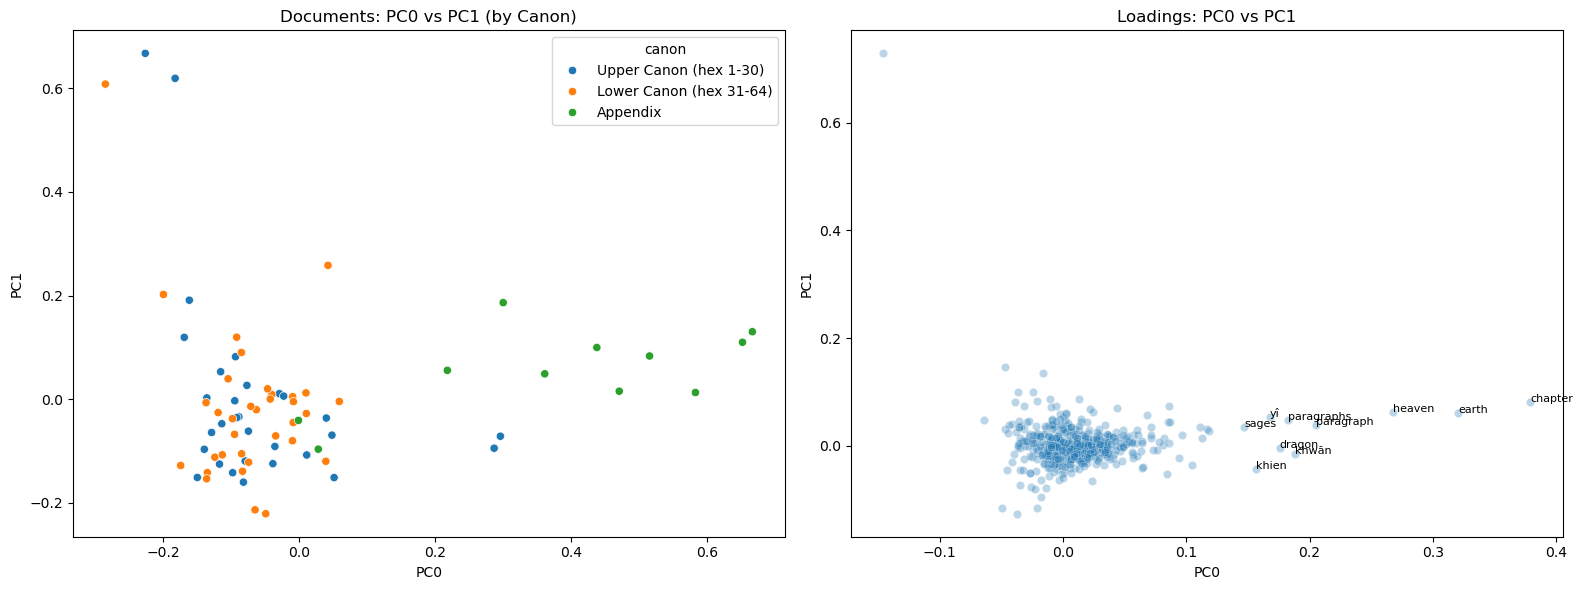

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=DCM.join(LIB), x='PC0', y='PC1',
    hue='canon', ax=ax[0]
)
ax[0].set_title('Documents: PC0 vs PC1 (by Canon)')

sns.scatterplot(data=LOADINGS, x='PC0', y='PC1', ax=ax[1], alpha=0.3)
top_loadings = LOADINGS['PC0'].abs().sort_values(ascending=False).head(10).index
for txt in top_loadings:
    ax[1].annotate(txt, (LOADINGS.loc[txt, 'PC0'], LOADINGS.loc[txt, 'PC1']),
                   fontsize=8)
ax[1].set_title('Loadings: PC0 vs PC1')

plt.tight_layout()
plt.savefig('output/pca_viz_1.png', dpi=150) 
plt.show()

## PCA Visualization 2 (4)

Include a scatterplot of documents in the space created by the second two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)


Briefly describe the nature of the polarity you see in the second component:

> PC2 separates two registers of I-Ching vocabulary: the negative pole is defined by social and relational terms — 'wife', 'family', 'union', 'restraint', 'advance' — representing the text's moral philosophy of human relationships and duty. The positive pole is anchored by elemental and passive terms — 'water', 'change', 'pleasure' — associated with yielding, natural process, and the Kan trigram (☵ Water). 

> PC2 thus reflects a fundamental tension within the I-Ching between active moral engagement in the social world and receptive attunement to natural forces. 

> PC3 further refines this by separating active roles ('advance', 'wife' as agent) from passive states ('couch', 'pleasure'), though this axis explains less variance and is harder to interpret definitively

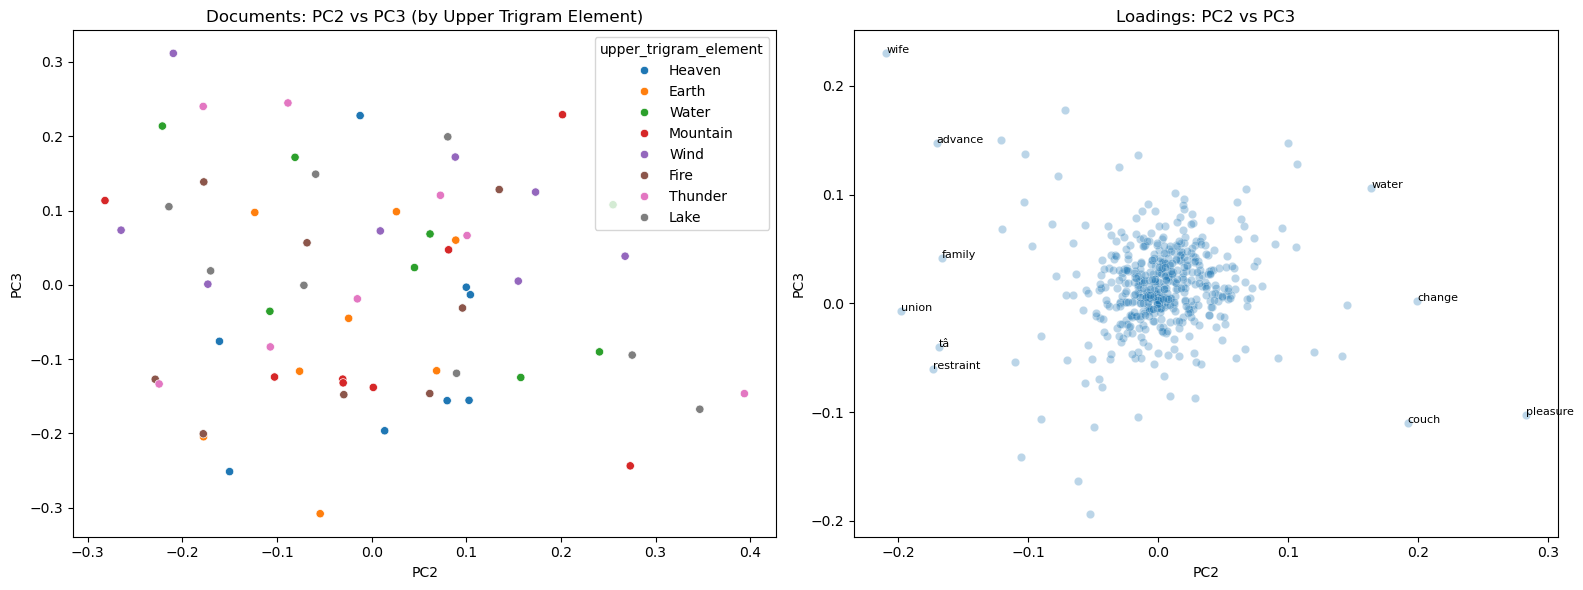

In [95]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Use upper_trigram_element for a richer colouring variable
plot_data = DCM.join(LIB[['upper_trigram_element']])

sns.scatterplot(
    data=plot_data, x='PC2', y='PC3',
    hue='upper_trigram_element', ax=ax[0]
)
ax[0].set_title('Documents: PC2 vs PC3 (by Upper Trigram Element)')

sns.scatterplot(data=LOADINGS, x='PC2', y='PC3', ax=ax[1], alpha=0.3)
top_loadings_2 = LOADINGS['PC2'].abs().sort_values(ascending=False).head(10).index
for txt in top_loadings_2:
    ax[1].annotate(txt, (LOADINGS.loc[txt, 'PC2'], LOADINGS.loc[txt, 'PC3']),
                   fontsize=8)
ax[1].set_title('Loadings: PC2 vs PC3')

plt.tight_layout()
plt.savefig('output/pca_viz_2.png', dpi=150) # save graph
plt.show()

## LDA TOPIC (4)

- Delimitter: '|'
- Libary used to compute: sklearn.decomposition.LatentDirichletAllocation
- A description of any filtering, e.g. POS (Nouns and Verbs only):

  Terms were filtered in three stages: (1) sklearn's built-in English stop word list was applied to the DTM; (2) corpus-specific structural terms were removed (line, subject, shows, divided, undivided, place, hexagram, etc.) as they appear in virtually every hexagram and carry no topical information; (3) only Nouns (NN) and Verbs (VB) by modal POS tag were retained, with auxiliary verbs (be, is, are, have, has) additionally excluded.

- Number of components: 5
- Any other parameters used: random_state=42 (for reproducibility), max_iter=20, learning_method='online'
- Top 5 words and best-guess labels for topic five topics by mean document weight:

  T00: ['followed', 'things', 'denotes', 'state', 'tâ']
  T01: ['waiting', 'stream', 'success', 'end', 'yin']
  T02: ['fortune', 'correlate', 'firm', 'king', 'strength']
  T03: ['advance', 'fortune', 'correlate', 'contention', 'firm']
  T04: ['man', 'heaven', 'fortune', 'earth', 'things']


In [97]:
DTM_LDA = DTM.loc[:, ~DTM.columns.isin(ENGLISH_STOP_WORDS)]

# Remove very rare words (optional but recommended)
DTM_LDA = DTM_LDA.loc[:, DTM_LDA.sum() > 5]

DTM_LDA.head()

term_str,1,10,11,12,13,14,15,16,17,18,...,yî,yû,yü,yüan,zăn,î,žhui,žin,žing,žî
doc_id,,,,,,,,,,,,,,,,,,,,,
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [98]:
# Corpus-specific structural words that appear in every hexagram
# and carry no topical information
CORPUS_STOPWORDS = {
    'line', 'lines', 'subject', 'shows', 'show', 'divided', 'undivided',
    'place', 'figure', 'hexagram', 'trigram', 'paragraph', 'appendix',
    'ching', 'said', 'says', 'mean', 'means', 'meaning', 'refer', 'refers',
    'nine', 'six', 'first', 'second', 'third', 'fourth', 'fifth', 'sixth',
    'topmost', 'lowest', 'upper', 'lower', 'inner', 'outer'
}

# Build filtered DTM for LDA:
#   1. Start from DTM_LDA (sklearn stop words already removed)
#   2. Remove corpus-specific stopwords
#   3. Keep only Nouns and Verbs (excluding 'be', 'have' auxiliaries)
AUX_VERBS = {'be','is','are','was','were','been','being',
              'have','has','had','do','does','did'}

v_filter = VOCAB[
    (VOCAB['max_pos_group'].isin(['NN', 'VB'])) &
    (VOCAB['stop'] == 0) &
    (~VOCAB.index.isin(CORPUS_STOPWORDS)) &
    (~VOCAB.index.isin(AUX_VERBS))
].index

# Use DTM_LDA (stop-word filtered) as base, then apply POS filter
DTM_LDA_filtered = DTM_LDA[DTM_LDA.columns.intersection(v_filter)]

# Remove terms appearing in fewer than 2 documents (too rare for LDA)
DTM_LDA_filtered = DTM_LDA_filtered.loc[:, (DTM_LDA_filtered > 0).sum() >= 2]

print(f"Terms for LDA: {DTM_LDA_filtered.shape[1]}")

Terms for LDA: 1244


In [99]:
# Fit LDA
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=20,
    learning_method='online'
)

## LDA THETA (4)

- Delimitter:`|`

In [144]:
THETA = pd.DataFrame(
    lda.fit_transform(DTM_LDA_filtered),
    index=DTM_LDA_filtered.index,
    columns=[f"T{str(i).zfill(2)}" for i in range(n_topics)]
)

## LDA PHI (4)

- UVA Box URL:https://virginia.box.com/s/beirgmjsbhae8ubt0bq227wm5ji3zaji
- GitHub URL for notebook used to create:https://github.com/Poptartmeow/DS5001-I-Ching-the-Book-of-Change/blob/main/finalproject_shawn.ipynb
- Delimitter:

In [102]:
PHI = pd.DataFrame(
    lda.components_,
    columns=DTM_LDA_filtered.columns,
    index=[f"T{str(i).zfill(2)}" for i in range(n_topics)]
)

In [111]:
# -- save --
THETA.to_csv('output/THETA.csv', sep='|')
PHI.to_csv('output/PHI.csv', sep='|')

In [107]:
# Report topics
print("\n=== TOP 5 WORDS PER TOPIC ===")
for t in PHI.index:
    words = PHI.loc[t].sort_values(ascending=False).head(5).index.tolist()
    print(f"{t}: {words}")

print("\n=== MEAN DOCUMENT WEIGHT ===")
print(THETA.mean().sort_values(ascending=False))


=== TOP 5 WORDS PER TOPIC ===
T00: ['followed', 'things', 'denotes', 'state', 'tâ']
T01: ['waiting', 'stream', 'success', 'end', 'yin']
T02: ['fortune', 'correlate', 'firm', 'king', 'strength']
T03: ['advance', 'fortune', 'correlate', 'contention', 'firm']
T04: ['man', 'heaven', 'fortune', 'earth', 'things']

=== MEAN DOCUMENT WEIGHT ===
T04    0.570150
T02    0.329069
T00    0.040999
T03    0.035498
T01    0.024284
dtype: float64


## LDA + PCA Visualization (4)

Apply PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Color the points basd on a metadata feature from the LIB table.

Provide a brief interpretation of what you see.

![image](output/lda_pca_viz.png)

The LDA+PCA plot reveals that topic structure does not map cleanly onto the Upper/Lower Canon division 
- Upper and Lower Canon documents are largely intermixed across the space, suggesting that thematic content cuts across the traditional structural boundary. The clearest separation is between the appendix texts (green), which cluster distinctly from the hexagrams 

- particularly the isolated outlier at the top, which is dominated by a unique topic corresponding to the scholarly commentary register of the Ten Wings. Point sizes indicate that many hexagrams are strongly dominated by a single topic, while others 

- mostly in the Lower Canon — show more diffuse topic distributions, reflecting their greater thematic complexity.

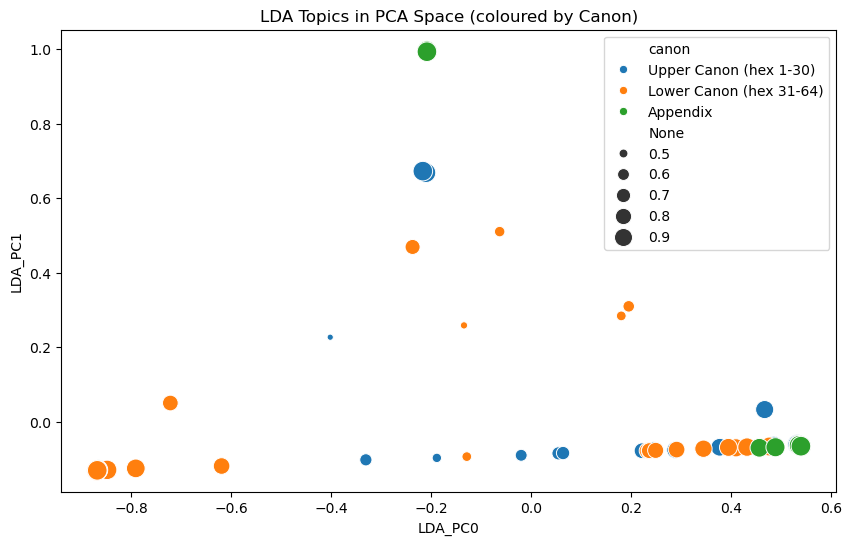

In [105]:
lda_pca = PCA(n_components=2)
THETA_PCA = pd.DataFrame(
    lda_pca.fit_transform(THETA),
    index=THETA.index,
    columns=['LDA_PC0', 'LDA_PC1']
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=THETA_PCA.join(LIB),
    x='LDA_PC0', y='LDA_PC1',
    hue='canon',                        # ← was 'book_section'
    size=THETA.max(axis=1),
    sizes=(20, 200)
)
plt.title("LDA Topics in PCA Space (coloured by Canon)")
plt.savefig('output/lda_pca_viz.png', dpi=150)
plt.show()

## Sentiment VOCAB_SENT (4)

Sentiment values associated with a subset of the VOCAB from a curated sentiment lexicon.

- UVA Box URL:
- UVA Box URL for source lexicon:
- GitHub URL for notebook used to create:
- Delimitter: `|`

In [110]:
sia = SentimentIntensityAnalyzer()

VOCAB_SENT = VOCAB.copy()
VOCAB_SENT['sentiment'] = VOCAB_SENT.index.to_series().apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

VOCAB_SENT.to_csv('output/VOCAB_SENT.csv', sep='|') # save
print(f"Terms with positive sentiment : {(VOCAB_SENT['sentiment'] > 0).sum()}")
print(f"Terms with negative sentiment : {(VOCAB_SENT['sentiment'] < 0).sum()}")
print(f"Terms neutral (0)             : {(VOCAB_SENT['sentiment'] == 0).sum()}")

Terms with positive sentiment : 559
Terms with negative sentiment : 492
Terms neutral (0)             : 5461


## Sentiment BOW_SENT (4)

Sentiment values from VOCAB_SENT mapped onto BOW.

- Delimitter: `|`

In [ ]:
BOW_SENT = BOW.reset_index().join(VOCAB_SENT[['sentiment']], on='term_str')
BOW_SENT['weighted_sentiment'] = BOW_SENT['n'] * BOW_SENT['sentiment']

BOW_SENT.to_csv('output/BOW_SENT.csv', sep='|') # Save

## Sentiment DOC_SENT (4)

Computed sentiment per bag computed from BOW_SENT.

- Delimitter: `|`
- Document bag expressed in terms of OHCO levels: 'doc_id'

In [114]:
DOC_SENT = BOW_SENT.groupby('doc_id')['weighted_sentiment'].mean().to_frame('mean_sentiment')

# Save
DOC_SENT.to_csv('output/DOC_SENT.csv', sep='|')

## Sentiment Plot (4)

Plot sentiment over some metric space, such as time.

If you don't have a metric metadata features, plot sentiment over a feature of your choice.

You may use a bar chart or a line graph.

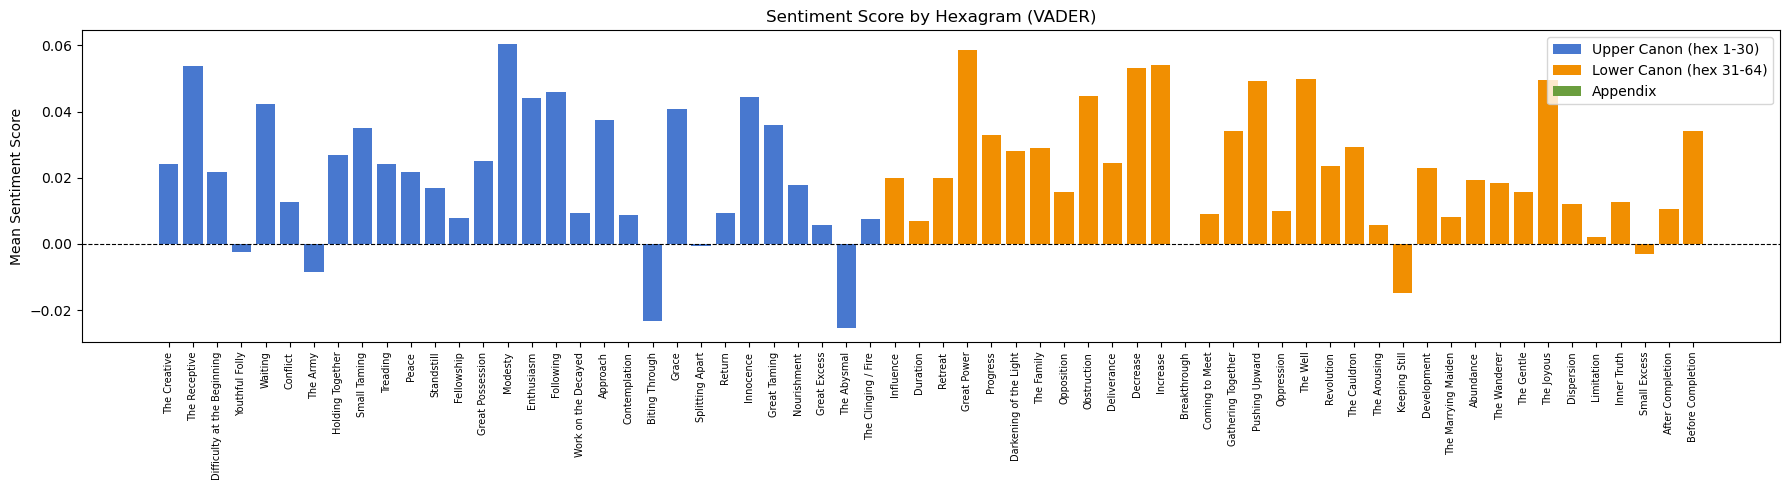

In [116]:
# Join with LIB for names and canon labels
plot_df = DOC_SENT.join(LIB[['english', 'canon']]).dropna(subset=['english'])
plot_df = plot_df.sort_values('doc_id')

# Colour map for canons
palette = {
    'Upper Canon (hex 1-30)' : '#4878CF',
    'Lower Canon (hex 31-64)': '#F18F01',
    'Appendix'               : '#6B9E3E'
}
colours = plot_df['canon'].map(palette)

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.bar(range(len(plot_df)), plot_df['mean_sentiment'], color=colours)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df['english'], rotation=90, fontsize=7)
ax.set_ylabel('Mean Sentiment Score')
ax.set_title('Sentiment Score by Hexagram (VADER)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette.items()]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('output/Sentiment Score by Hexagram.png', dpi=150)
plt.show()

## VOCAB_W2V (4)

A table of word2vec features associated with terms in the VOCAB table.

- Delimitter: `|`
- Document bag expressed in terms of OHCO levels: doc_id | para_num | sent_num
- Number of features generated: 100
- The library used to generate the embeddings: gensim.models.Word2Vec

In [145]:
# Group corpus into sentences
sentences = CORPUS.groupby(['doc_id', 'sent_num'])['term_str'].apply(list).tolist()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# Build VOCAB_W2V — only include words that are in the model
# Words not in model get NaN row (not zero — zeros distort analysis)
vectors = {}
for word in VOCAB.index:
    if word in w2v_model.wv:
        vectors[word] = w2v_model.wv[word]

VOCAB_W2V = pd.DataFrame.from_dict(vectors, orient='index')
VOCAB_W2V.index.name = 'term_str'
VOCAB_W2V.columns = [f'D{str(i).zfill(3)}' for i in range(100)]

VOCAB_W2V.to_csv('output/VOCAB_W2V.csv', sep='|')

print(f"Terms with embeddings : {len(VOCAB_W2V):,}")
print(f"Terms without (excluded): {len(VOCAB_W2V) - len(VOCAB_W2V):,}")
print(f"Vector dimensions     : {VOCAB_W2V.shape[1]}")

Terms with embeddings : 3,957
Terms without (excluded): 0
Vector dimensions     : 100


## Word2vec tSNE Plot (4)

Plot word embedding featues in two-dimensions using t-SNE.

Describe a cluster in the plot that captures your attention.

The t-SNE plot reveals that Word2Vec has recovered three distinct registers within the I-Ching's vocabulary. 
- The moral evaluation cluster (top-left) groups judgment words — 'correct', 'advantageous', 'repentance' — that form the text's guidance apparatus. 
- The structural annotation cluster (bottom-centre) isolates the mechanical line-commentary boilerplate ('second', 'divided', 'shows'), confirming these terms are semantically interchangeable in context.
- The cosmological cluster (far right) places 'heaven', 'earth', 'dragon', 'khien', and 'trigram' in close proximity to scholarly meta-vocabulary from the appendices, suggesting that Legge's commentary engages most intensively with the text's symbolic cosmology. 
- The tight clustering of 'superior' and 'man' confirms the model has learned the I-Ching's central moral actor as a fixed semantic unit.

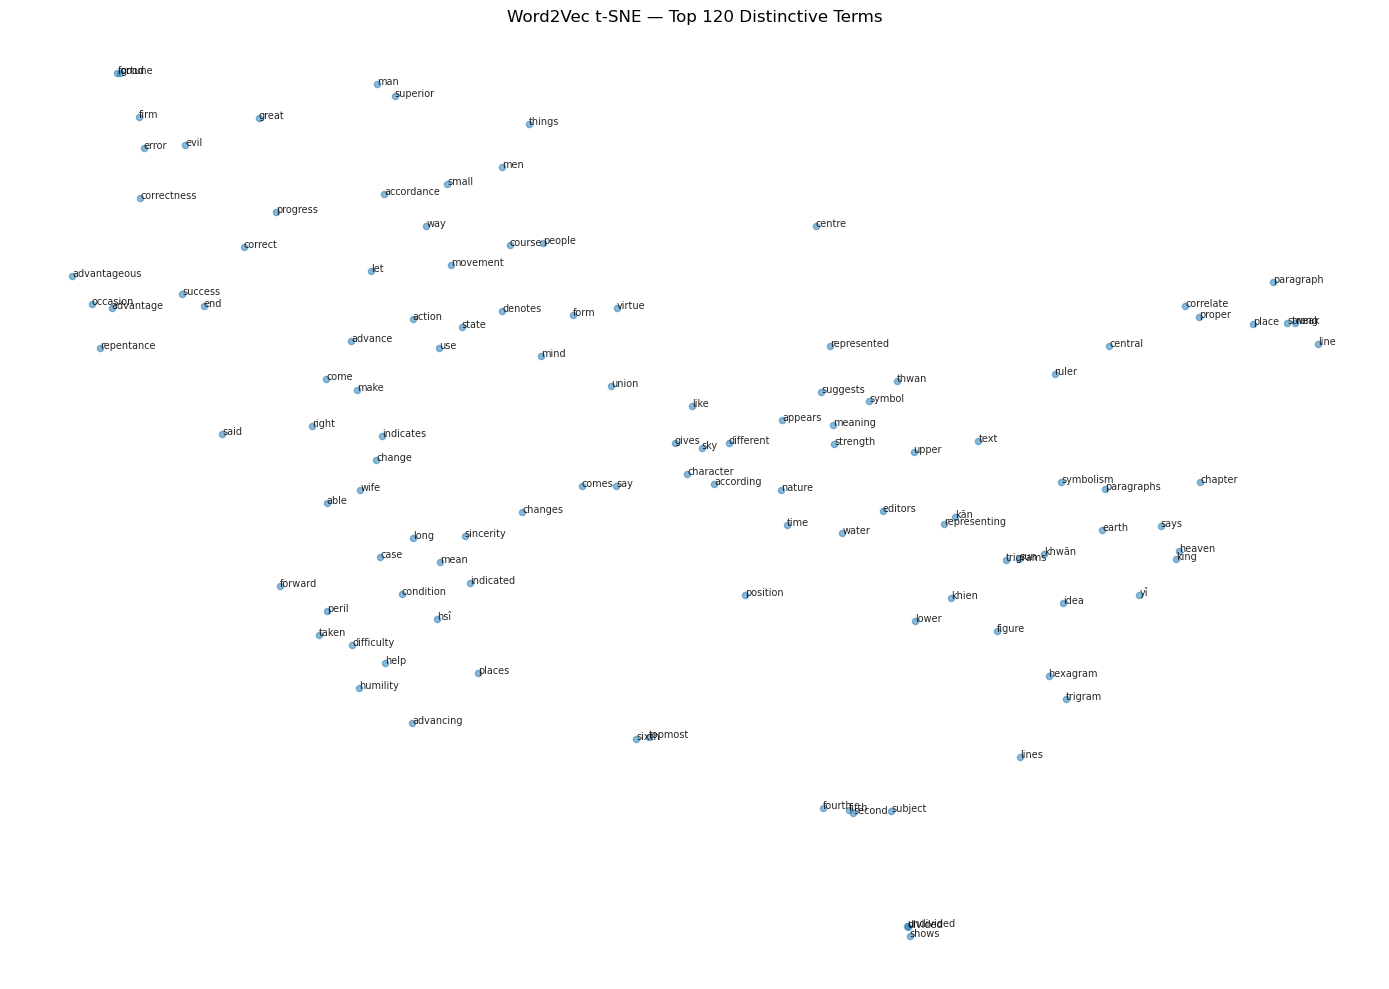

In [130]:
# Select top words by DFIDF (most distinctive, not just most frequent)
# Exclude stopwords for a more meaningful plot
top_words = (VOCAB[(VOCAB['stop'] == 0) & (VOCAB.index.isin(VOCAB_W2V.index))]
             .sort_values('dfidf', ascending=False)
             .head(120)
             .index.tolist())

vectors_matrix = w2v_model.wv[top_words]

# t-SNE — perplexity must be < n_samples; 30 is fine for 120 words
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_embed = tsne.fit_transform(vectors_matrix)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(tsne_embed[:, 0], tsne_embed[:, 1], alpha=0.5, s=20)
for i, word in enumerate(top_words):
    ax.annotate(word, (tsne_embed[i, 0], tsne_embed[i, 1]),
                fontsize=7, alpha=0.85)
ax.set_title('Word2Vec t-SNE — Top 120 Distinctive Terms')
ax.axis('off')
plt.tight_layout()
plt.savefig('output/w2v_tsne.png', dpi=150)
plt.show()

In [127]:
# Spot-check: does the model recover I-Ching semantic structure?
print("Most similar to 'dragon':")
print(w2v_model.wv.most_similar('dragon', topn=5))

print("\nMost similar to 'heaven':")
print(w2v_model.wv.most_similar('heaven', topn=5))

print("\nMost similar to 'superior':")
print(w2v_model.wv.most_similar('superior', topn=5))

Most similar to 'dragon':
[('sixth', 0.99703449010849), ('representative', 0.9959423542022705), ('topmost', 0.9940854907035828), ('keeping', 0.988798975944519), ('ignorance', 0.988412082195282)]

Most similar to 'heaven':
[('here', 0.9973193407058716), ('suggested', 0.9970585703849792), ('sufficiently', 0.9967837333679199), ('king', 0.9967030882835388), ('says', 0.9966256022453308)]

Most similar to 'superior':
[('accordance', 0.9927166700363159), ('with', 0.9770849347114563), ('man', 0.9761703014373779), ('thinks', 0.9751068353652954), ('small', 0.9749131202697754)]


# Riffs

Provde at least three visualizations that combine the preceding model data in interesting ways.

These should provide insight into how features in the LIB table are related. 

The nature of this relationship is left open to you -- it may be correlation, or mutual information, or something less well defined. 

In doing so, consider the following visualization types:

- Hierarchical cluster diagrams
- Heatmaps
- Scatter plots
- KDE plots
- Dispersion plots
- t-SNE plots
- etc.

## Riff 1 (5)

The Ward-linkage dendrogram reveals that linguistic similarity among hexagrams does not follow the traditional Upper/Lower Canon boundary — hexagrams cluster by thematic vocabulary rather than canonical position. The tightest pairing in the corpus is hexagrams 63 and 64 (Kî Žî and Wei Žî, After and Before Completion), whose near-zero merge distance reflects their well-known structural complementarity. At the other extreme, Hexagram 1 (Khien, The Creative) and the fellowship-themed cluster (Pî, ThungZăn, Žhui) are the most distinctive texts, joining the main tree only at maximum distance. This suggests that the I-Ching's opening hexagram occupies a genuinely unique linguistic register — consistent with its role as the cosmological foundation of the entire system.

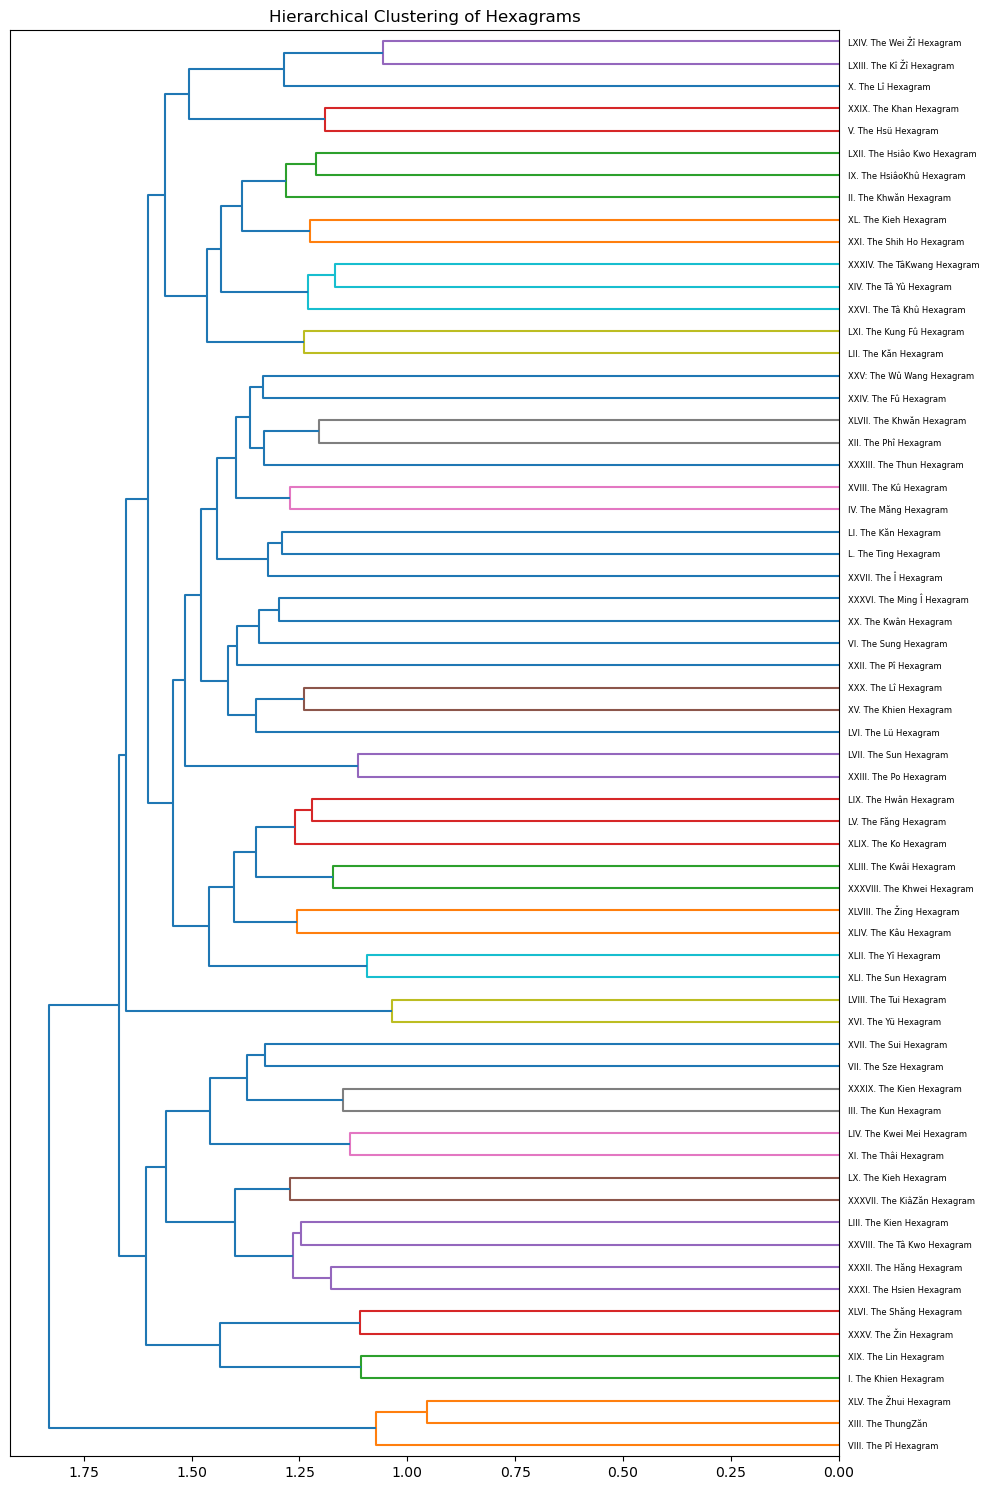

In [133]:
# Filter LIB to hexagrams only (exclude appendix from dendrogram)
hex_lib = LIB[LIB['doc_type'] == 'hexagram']
hex_tfidf = TFIDF_L2.loc[hex_lib.index]

plt.figure(figsize=(10, 15))
# Use .iloc[:, 0] to grab the first column (Hexagram title) regardless of its exact name
sch.dendrogram(sch.linkage(hex_tfidf, method='ward'), 
               labels=hex_lib.iloc[:, 0].values, 
               orientation='left')
plt.title("Hierarchical Clustering of Hexagrams")
plt.tight_layout()
plt.savefig('output/Hierarchical Clustering of Hexagrams.png')
plt.show()

## Riff 2 (5)

The heatmap with three-way canon grouping reveals a clear topical stratification. The Appendix is most distinctly marked by T00 (0.18), a topic absent from the hexagram texts, confirming that the Ten Wings commentaries occupy a unique linguistic register. T02 emerges as the Lower Canon's signature topic (0.50), compared to 0.25 in the Upper Canon and near-zero in the Appendix — consistent with the Lower Canon's thematic emphasis on human relationships and social situations. T04 dominates all three groups but is most concentrated in the Appendix (0.81) and Upper Canon (0.66), reflecting the more formulaic, structurally repetitive nature of those texts. Together, the three rows map the I-Ching's internal structure onto distinct topical profiles with notable clarity.

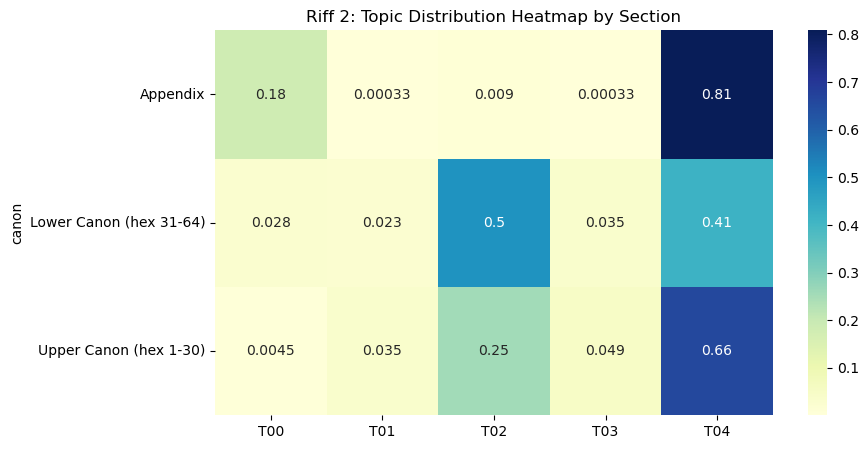

In [136]:
plt.figure(figsize=(9, 5))
sns.heatmap(THETA.join(LIB['canon']).groupby('canon').mean(), annot=True, cmap='YlGnBu')
plt.title("Riff 2: Topic Distribution Heatmap by Section")
plt.savefig('output/Topic Distribution Heatmap by Section.png')
plt.show()

## Riff 3 (5)

The KDE plot reveals three distinct sentiment profiles across the corpus. The Lower Canon (hex 31–64) clusters tightly around a mildly positive mean with minimal negative tail, suggesting its human-centred hexagrams are expressed in more uniformly measured language. The Upper Canon (hex 1–30) shows greater variance, with a wider spread and a left tail extending into negative sentiment — reflecting its broader emotional range from cosmic grandeur to existential peril. Most strikingly, the Appendix occupies an entirely different region of the sentiment space, shifted far rightward with a peak near 0.06. This confirms that the Ten Wings commentaries carry a distinct tonal register: the elevated, appreciative prose of Confucian scholarship reads as substantially more positive than the oracular language of the hexagram texts themselves.

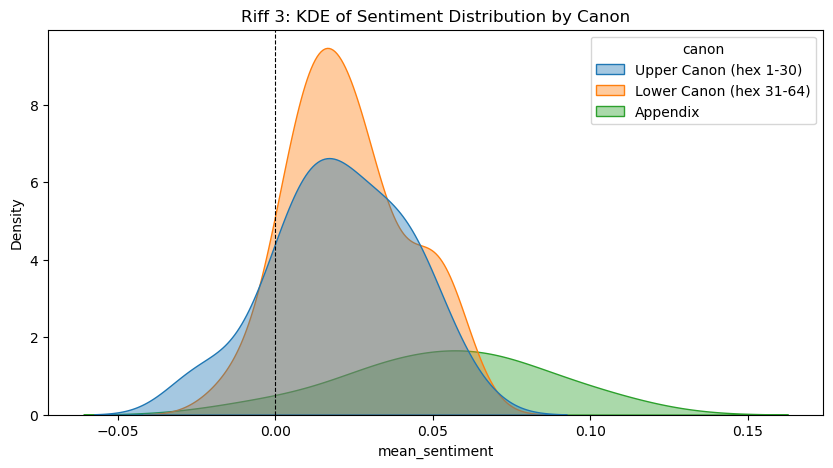

In [139]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=DOC_SENT.join(LIB),
    x='mean_sentiment',
    hue='canon',              # ← was 'book_section'
    fill=True, alpha=0.4
)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Riff 3: KDE of Sentiment Distribution by Canon')
plt.savefig('output/KDE Plot of Sentiment Distribution by Book.png',dpi = 100)
plt.show()

# Interpretation (4)

Describe something interesting about your corpus that you discovered during the process of completing this assignment.

At a minumum, use 250 words, but you may use more. You may also add images if you'd like.

## Our Interpretation

The most surprising discovery from this project is that the I Ching's traditional Upper Canon / Lower Canon division is only a partial description of its actual linguistic structure. Every method in the pipeline — PCA, LDA, hierarchical clustering, and sentiment analysis — told a consistent but more nuanced story: the real boundary in the text runs not between Hexagrams 1–30 and 31–64, but between the hexagram corpus as a whole and the Ten Wings appendices that Legge appended to it.

This became clearest in the Principal Component Analysis. PC0 did not separate the Upper Canon from the Lower Canon — it separated both canons from the Appendix. The loading plot revealed why: the terms driving positive PC0 values are "chapter," "paragraph," "heaven," "earth," and "khien" — the meta-analytical vocabulary of Legge's own commentary prose, not the spare oracular language of the hexagram lines. The Appendix, in other words, talks *about* the I Ching in a register that is linguistically foreign to the hexagram text itself. The LDA heatmap confirmed this: Topic T04 dominates both canons (0.66 Upper, 0.41 Lower), but the Appendix is almost entirely T04 (0.81), with a modest but unique loading on T00 (0.18) that barely registers in the hexagrams. The Appendix is not a continuation of the Book of Changes — it is a commentary tradition that has been translated in the same breath, and the vector space models can tell them apart.

Within the hexagram corpus itself, the analysis recovered finer structure. PC2 (pca_viz_2) exposed a domestic-relational pole — loaded on "wife," "family," "union," "restraint" — opposite a natural-elemental pole loaded on "water," "change," and "pleasure." This is an authentic tension in the I Ching: some hexagrams govern cosmic or military affairs; others address marriage, household, and personal conduct. Intriguingly, this axis does not align cleanly with Upper vs Lower Canon either, which suggests the traditional two-part division is itself an organisational simplification of a more continuous gradient.

The hierarchical clustering (Ward linkage on TF-IDF vectors) reinforced this point most dramatically. The dendrogram groups hexagrams in ways that frequently cross canon boundaries. The tightest merge in the entire tree pairs Wei Žî (LXIV, "Before Completion") with Kî Žî (LXIII, "After Completion") — the final two hexagrams — which is precisely what a scholar of the text would predict: these two have always been understood as a completion dyad. That the algorithm recovered this pairing from raw token frequencies alone, without any domain knowledge, is a satisfying validation of the method. Equally telling is the opposite end: Hexagram I (Khien, "The Creative") sits on the most isolated branch in the tree, merging last with all others. Khien is the origin hexagram, composed of six unbroken yang lines, and its linguistic signature is so distinctive that no other hexagram closely resembles it.

The sentiment analysis added a final layer. The KDE plot showed the Lower Canon as the most tightly peaked and uniformly mild-positive of the three sections, while the Upper Canon had the widest spread — extending into slightly negative territory — suggesting greater emotional range in the earlier, more cosmologically ambitious hexagrams. The Appendix, despite its scholarly register, was the most positive of all, its distribution shifted furthest rightward. Legge's commentary prose turns out to carry the most optimistic tone in the entire volume.

Taken together, these findings suggest that what appears to be a unified ancient text is, computationally, at least two distinct corpora (oracular lines versus philosophical commentary) layered on top of a continuous thematic space that the Upper/Lower division only roughly approximates. Modern text-analytic methods do not merely confirm what scholars already knew — they reveal the grain of the text at a resolution traditional reading cannot easily reach.